In [1]:
"""
========================================================
  PROJECT 3: Monte Carlo Stock Price Simulator
========================================================
  Concepts covered:
    - Geometric Brownian Motion (GBM): the standard model
      for stock price evolution
    - Stochastic processes: drift (μ) and diffusion (σ)
    - The Wiener process (random shocks)
    - Simulating thousands of price paths
    - Interpreting a cone of outcomes
    - Connecting simulation results to analytical solutions

  Builds on Projects 1 & 2:
    - μ and σ are estimated from historical data (Project 1)
    - The same log-return framework underlies GBM
    - Simulation is the numerical engine behind Project 5
      (Monte Carlo options pricing)

  Requirements:
    pip install yfinance pandas numpy matplotlib scipy

  Usage:
    Edit the CONFIG block below, then run:
      python project3_monte_carlo_simulator.py
========================================================
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats
import yfinance as yf

In [2]:
# Configuration

#user inputted ticker
def get_valid_ticker(max_attempts=3, fallback="VOO"):
    for attempt in range(1, max_attempts + 1):
        raw_input = input(f"Enter a valid stock ticker: ")
        candidates = [t.strip().upper() for t in raw_input.split(",")][:4]

        # Validate ticker by trying to download a small amount of data
        data = yf.download(raw_input, period="5d", progress=False, auto_adjust=True)
        if not data.empty:
            print(f"  ✓ Ticker is valid: {raw_input}\n")
            return raw_input
        else:
            print(f"  ✗ Could not find data for: {raw_input}")
            if attempt < max_attempts:
                print(f"  Please try again with a valid ticker name. ({max_attempts - attempt} attempt(s) remaining)\n")
            else:
                print(f"  Max attempts reached. Running analysis on fallback ticker: {fallback}\n")
                return fallback
        

TICKER       = get_valid_ticker()
START_DATE   = "2023-01-01"  # Historical data start (for estimating μ, σ)
END_DATE     = "2026-01-01"  # Historical data end
HORIZON      = 252           # Simulation horizon in trading days (1 year)
N_SIMS       = 1000          # Number of simulated price paths
TRADING_DAYS = 252           # Trading days per year
tbill = yf.Ticker("^IRX") # 13-week (3-month) Treasury bill yield
RISK_FREE = tbill.fast_info["lastPrice"] / 100  # convert from percentage to decimal
print(f"Current risk-free rate: {RISK_FREE:.2%}")
CONFIDENCE   = 0.95          # Confidence interval for the cone

Enter a valid stock ticker: DELL
  ✓ Ticker is valid: DELL

Current risk-free rate: 3.59%


In [3]:
#Data & Parameter Estimation

def fetch_prices(ticker: str, start: str, end: str) -> pd.Series:
    print(f"Downloading historical data for {ticker} ...")
    raw    = yf.download(ticker, start=start, end=end,
                         auto_adjust=True, progress=False)
    prices = raw["Close"].squeeze()
    print(f"  Got {len(prices)} rows from {prices.index[0].date()} "
          f"to {prices.index[-1].date()}\n")
    return prices


def estimate_parameters(prices: pd.Series) -> tuple[float, float, float]:
    """
    Estimate the two GBM parameters from historical price data.

      μ (mu)    — daily drift: average daily log return
      σ (sigma) — daily volatility: std dev of daily log returns

    These are the DAILY parameters. We'll scale them inside the
    simulation using dt = 1/252.

    Returns: (mu_annual, sigma_annual, S0)
      - annualised for display purposes
      - S0 is the last observed price (our simulation starting point)
    """
    log_returns  = np.log(prices / prices.shift(1)).dropna()
    mu_daily     = log_returns.mean()
    sigma_daily  = log_returns.std()

    mu_annual    = mu_daily * TRADING_DAYS
    sigma_annual = sigma_daily * np.sqrt(TRADING_DAYS)
    S0           = float(prices.iloc[-1])

    print(f"  Estimated parameters for {TICKER}:")
    print(f"    S0 (starting price)   : ${S0:.2f}")
    print(f"    μ  (annual drift)     : {mu_annual:.2%}")
    print(f"    σ  (annual volatility): {sigma_annual:.2%}\n")

    return mu_annual, sigma_annual, S0


#Geometric Brownian Motion

def simulate_gbm(
    S0: float,
    mu: float,
    sigma: float,
    horizon: int,
    n_sims: int,
    seed: int = 42
) -> np.ndarray:
    """
    Simulate stock price paths using Geometric Brownian Motion.

    The GBM formula for one time step dt is:

        S(t+dt) = S(t) × exp[(μ - ½σ²)dt  +  σ√dt × Z]
                              ───────────     ───────────
                               drift term     diffusion term
                               (deterministic) (random shock)

    where Z ~ N(0,1) is a standard normal random variable.

    Why (μ - ½σ²) and not just μ?
      This is Itô's correction. Because prices are log-normally distributed,
      the average LOG return is μ - ½σ², not μ. Without this term the
      simulation would systematically overestimate prices over time.
      (We'll revisit this in Project 5 when pricing options.)

    Parameters
    ----------
    S0      : starting price
    mu      : annualised drift
    sigma   : annualised volatility
    horizon : number of trading days to simulate
    n_sims  : number of independent paths
    seed    : random seed for reproducibility

    Returns
    -------
    paths : np.ndarray of shape (horizon + 1, n_sims)
            Row 0 is S0 for all paths; each column is one simulated path.
    """
    rng  = np.random.default_rng(seed)
    dt   = 1 / TRADING_DAYS

    # Draw all random shocks at once: shape (horizon, n_sims)
    Z = rng.standard_normal((horizon, n_sims))

    # Daily log return for each step
    drift     = (mu - 0.5 * sigma**2) * dt
    diffusion = sigma * np.sqrt(dt) * Z        # shape: (horizon, n_sims)

    # Cumulative sum of log returns → price paths
    log_returns  = drift + diffusion            # shape: (horizon, n_sims)
    cum_log_ret  = np.cumsum(log_returns, axis=0)

    # Prepend row of zeros (t=0) then exponentiate
    cum_log_ret  = np.vstack([np.zeros((1, n_sims)), cum_log_ret])
    paths        = S0 * np.exp(cum_log_ret)     # shape: (horizon+1, n_sims)

    return paths


#Analytics

def analytical_moments(
    S0: float,
    mu: float,
    sigma: float,
    horizon: int
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    GBM has a known analytical solution — we can compute the expected
    price and confidence interval exactly, without simulation.

    Expected price at time T:   E[S(T)] = S0 × exp(μT)
    Std dev of log price:       σ_T     = σ × √T

    The confidence interval uses the log-normal quantiles.
    Comparing the simulated cone to the analytical one is a good
    sanity check that our simulation is correct.
    """
    t         = np.arange(horizon + 1) / TRADING_DAYS
    E_ST      = S0 * np.exp(mu * t)

    alpha     = 1 - CONFIDENCE
    z         = stats.norm.ppf(1 - alpha / 2)
    sigma_t   = sigma * np.sqrt(t)
    log_mean  = np.log(S0) + (mu - 0.5 * sigma**2) * t

    upper     = np.exp(log_mean + z * sigma_t)
    lower     = np.exp(log_mean - z * sigma_t)

    return E_ST, lower, upper


def terminal_price_stats(paths: np.ndarray) -> dict:
    """Summary statistics for the distribution of terminal (final) prices."""
    terminal = paths[-1, :]
    return {
        "mean":   np.mean(terminal),
        "median": np.median(terminal),
        "std":    np.std(terminal),
        "p5":     np.percentile(terminal, 5),
        "p25":    np.percentile(terminal, 25),
        "p75":    np.percentile(terminal, 75),
        "p95":    np.percentile(terminal, 95),
        "prob_above_S0": np.mean(terminal > paths[0, 0]),
    }

In [4]:
#Dashboard Creation Definitions (& Summary)#

def plot_dashboard(
    prices: pd.Series,
    paths: np.ndarray,
    mu: float,
    sigma: float,
    S0: float
) -> None:

    horizon   = paths.shape[0] - 1
    t_hist    = np.arange(len(prices))
    t_sim     = np.arange(horizon + 1)
    E_ST, lower, upper = analytical_moments(S0, mu, sigma, horizon)
    stats_    = terminal_price_stats(paths)
    terminal  = paths[-1, :]

    # Color palette
    BG        = "#0A0E1A"
    PANEL     = "#0F1624"
    GRID      = "#1A2035"
    ACCENT1   = "#00D4FF"   # cyan — expected path
    ACCENT2   = "#FF6B6B"   # red — upper bound
    ACCENT3   = "#FFD93D"   # yellow — lower bound
    SIM_COL   = "#3D6B8F"   # muted blue — simulation paths
    HIST_COL  = "#7C3AED"   # purple — historical prices
    TEXT      = "#94A3B8"

    fig = plt.figure(figsize=(16, 11), facecolor=BG)
    fig.suptitle(f"Monte Carlo Price Simulator — {TICKER}  "
                 f"(μ={mu:.1%}, σ={sigma:.1%}, {N_SIMS:,} paths)",
                 fontsize=18, fontweight="bold", color="white",
                 fontfamily="monospace", y=0.97)

    gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.35)

    def style_ax(ax: plt.Axes) -> None:
        ax.set_facecolor(PANEL)
        ax.tick_params(axis="both", color=GRID, labelcolor=TEXT, labelsize=9)
        ax.spines[:].set_color(GRID)
        for spine in ax.spines.values():
            spine.set_linewidth(0.5)

    # ── Panel 1: Simulated price paths + cone (full top row) ──
    ax1 = fig.add_subplot(gs[0, :])
    # Draw a sample of paths so the plot isn't too cluttered
    sample_idx = np.random.choice(N_SIMS, size=min(200, N_SIMS), replace=False)
    for i in sample_idx:
        ax1.plot(t_sim, paths[:, i], color=SIM_COL, alpha=0.08, linewidth=0.6)
    # Confidence cone (analytical)
    ax1.fill_between(t_sim, lower, upper,
                     color=ACCENT1, alpha=0.08, label=f"{CONFIDENCE:.0%} CI (analytical)")
    ax1.plot(t_sim, upper, color=ACCENT2, linewidth=1.2, linestyle="--",
             label=f"Upper {CONFIDENCE:.0%} bound")
    ax1.plot(t_sim, lower, color=ACCENT3, linewidth=1.2, linestyle="--",
             label=f"Lower {CONFIDENCE:.0%} bound")
    ax1.plot(t_sim, E_ST,  color=ACCENT1, linewidth=2.0,
             label="E[S(T)] — analytical mean")
    ax1.plot(t_sim, np.median(paths, axis=1), color="white", linewidth=1.5,
             linestyle=":", label="Simulated median")
    ax1.axhline(S0, color="#4B5563", linewidth=0.8, linestyle="--")
    ax1.set_title(f"Simulated Price Paths ({N_SIMS:,} simulations, "
                  f"{horizon}-day horizon)", color="white", fontsize=11, pad=8)
    ax1.set_xlabel("Trading Days", color=TEXT, fontsize=9)
    ax1.set_ylabel("Price ($)", color=TEXT, fontsize=9)
    ax1.legend(fontsize=8, framealpha=0.15, labelcolor="white",
               loc="upper left", ncol=2)
    ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x:.0f}"))
    style_ax(ax1)

    # ── Panel 2: Terminal price distribution ──
    ax2 = fig.add_subplot(gs[1, 0])
    n_bins = 60
    counts, bin_edges, patches = ax2.hist(terminal, bins=n_bins,
                                           edgecolor="none", color=SIM_COL)
    # Color bars by percentile region
    for patch, left in zip(patches, bin_edges[:-1]):
        if left < stats_["p5"]:
            patch.set_facecolor("#FF6B6B")
        elif left > stats_["p95"]:
            patch.set_facecolor("#FF6B6B")
        else:
            patch.set_facecolor(SIM_COL)
    ax2.axvline(stats_["mean"],   color=ACCENT1, linewidth=1.5,
                linestyle="-",  label=f'Mean   ${stats_["mean"]:.0f}')
    ax2.axvline(stats_["median"], color="white", linewidth=1.5,
                linestyle=":",  label=f'Median ${stats_["median"]:.0f}')
    ax2.axvline(stats_["p5"],     color=ACCENT2, linewidth=1.2,
                linestyle="--", label=f'5th %ile ${stats_["p5"]:.0f}')
    ax2.axvline(stats_["p95"],    color=ACCENT2, linewidth=1.2,
                linestyle="--", label=f'95th %ile ${stats_["p95"]:.0f}')
    ax2.axvline(S0, color="#4B5563", linewidth=1.0,
                linestyle="-", label=f"S0 ${S0:.0f}")
    ax2.set_title("Terminal Price Distribution", color="white", fontsize=11, pad=8)
    ax2.set_xlabel("Price ($)", color=TEXT, fontsize=9)
    ax2.set_ylabel("Frequency", color=TEXT, fontsize=9)
    ax2.legend(fontsize=7.5, framealpha=0.15, labelcolor="white")
    ax2.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x:.0f}"))
    style_ax(ax2)

    # ── Panel 3: Log-normal fit check ──
    ax3 = fig.add_subplot(gs[1, 1])
    log_terminal = np.log(terminal)
    mu_fit, sigma_fit = stats.norm.fit(log_terminal)
    x = np.linspace(log_terminal.min(), log_terminal.max(), 200)
    ax3.hist(log_terminal, bins=50, density=True,
             color=HIST_COL, alpha=0.6, edgecolor="none",
             label="Simulated log-prices")
    ax3.plot(x, stats.norm.pdf(x, mu_fit, sigma_fit),
             color=ACCENT1, linewidth=2.0,
             label=f"Normal fit\n(μ={mu_fit:.2f}, σ={sigma_fit:.2f})")
    ax3.set_title("Log-Price Distribution (GBM → Log-Normal)", color="white",
                  fontsize=11, pad=8)
    ax3.set_xlabel("log(Terminal Price)", color=TEXT, fontsize=9)
    ax3.set_ylabel("Density", color=TEXT, fontsize=9)
    ax3.legend(fontsize=8, framealpha=0.15, labelcolor="white")
    style_ax(ax3)

    plt.savefig("project3_dashboard.png", dpi=150,
                bbox_inches="tight", facecolor=BG)
    print("  Chart saved → project3_dashboard.png")
    plt.show()


def print_summary(
    S0: float,
    mu: float,
    sigma: float,
    paths: np.ndarray
) -> None:
    s = terminal_price_stats(paths)
    E_ST, lower, upper = analytical_moments(S0, mu, sigma, HORIZON)

    print("=" * 58)
    print("  SIMULATION RESULTS")
    print("=" * 58)
    print(f"  Starting price (S0)       : ${S0:.2f}")
    print(f"  Simulation horizon        : {HORIZON} trading days (1 year)")
    print(f"  Number of paths           : {N_SIMS:,}")
    print()
    print(f"  --- Terminal Price Statistics ---")
    print(f"  Simulated mean            : ${s['mean']:.2f}")
    print(f"  Analytical E[S(T)]        : ${E_ST[-1]:.2f}  ← should be close")
    print(f"  Simulated median          : ${s['median']:.2f}")
    print(f"  Std deviation             : ${s['std']:.2f}")
    print()
    print(f"  --- Confidence Interval ({CONFIDENCE:.0%}) ---")
    print(f"  Simulated  5th percentile : ${s['p5']:.2f}")
    print(f"  Analytical lower bound    : ${lower[-1]:.2f}  ← should be close")
    print(f"  Simulated 95th percentile : ${s['p95']:.2f}")
    print(f"  Analytical upper bound    : ${upper[-1]:.2f}  ← should be close")
    print()
    print(f"  Probability price > S0    : {s['prob_above_S0']:.1%}")
    print("=" * 58)

  Got 752 rows from 2023-01-03 to 2025-12-31

  Estimated parameters for DELL:
    S0 (starting price)   : $125.33
    μ  (annual drift)     : 39.82%
    σ  (annual volatility): 49.19%

Running 1,000 simulations over 252 trading days...
  Done.

  SIMULATION RESULTS
  Starting price (S0)       : $125.33
  Simulation horizon        : 252 trading days (1 year)
  Number of paths           : 1,000

  --- Terminal Price Statistics ---
  Simulated mean            : $187.88
  Analytical E[S(T)]        : $186.64  ← should be close
  Simulated median          : $163.49
  Std deviation             : $103.03

  --- Confidence Interval (95%) ---
  Simulated  5th percentile : $74.74
  Analytical lower bound    : $63.05  ← should be close
  Simulated 95th percentile : $364.80
  Analytical upper bound    : $433.72  ← should be close

  Probability price > S0    : 70.7%

Generating dashboard...
  Chart saved → project3_dashboard.png


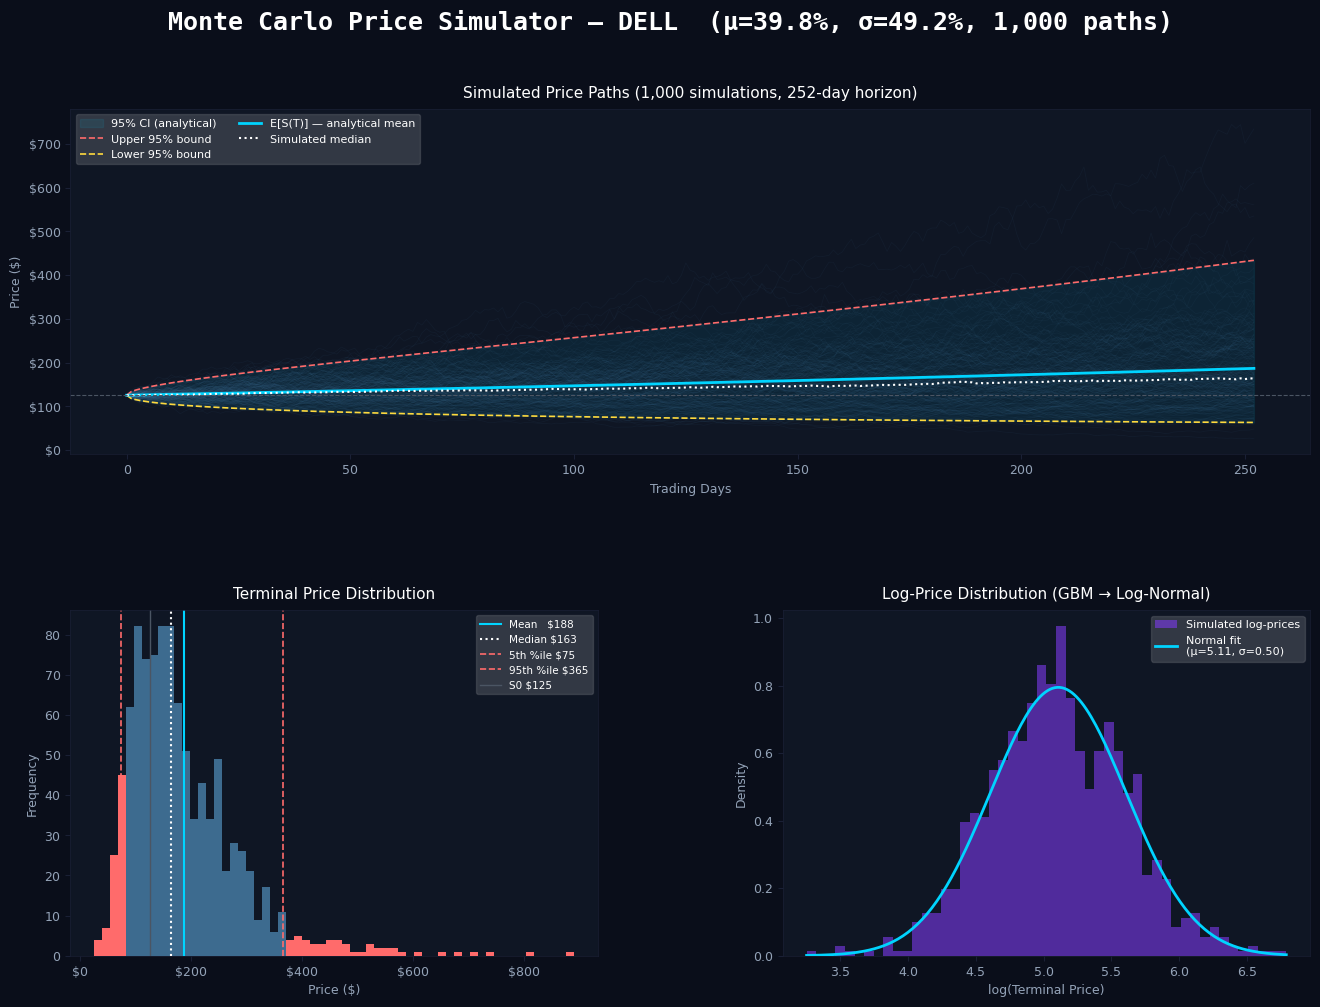

In [5]:
def main() -> None:
    # 1. Load historical prices
    prices = fetch_prices(TICKER, START_DATE, END_DATE)

    # 2. Estimate GBM parameters from history
    mu, sigma, S0 = estimate_parameters(prices)

    # 3. Run Monte Carlo simulation
    print(f"Running {N_SIMS:,} simulations over {HORIZON} trading days...")
    paths = simulate_gbm(S0, mu, sigma, HORIZON, N_SIMS)
    print("  Done.\n")

    # 4. Print summary (simulation vs analytical)
    print_summary(S0, mu, sigma, paths)

    # 5. Plot dashboard
    print("\nGenerating dashboard...")
    plot_dashboard(prices, paths, mu, sigma, S0)


if __name__ == "__main__":
    main()